In [2]:
# If kagglehub is not installed, uncomment the next line
# !pip install kagglehub

import os
import glob
import warnings
import joblib
import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset downloaded to:
/kaggle/input/ibm-hr-analytics-attrition-dataset


In [5]:
csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [6]:
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")

csv_path = csv_files[0]

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("CSV path:", csv_path)

Dataset loaded successfully!
CSV path: /kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [7]:
print("Number of instances:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of instances: 1470
Number of columns: 35


In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
print("Column names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:

1. Age
2. Attrition
3. BusinessTravel
4. DailyRate
5. Department
6. DistanceFromHome
7. Education
8. EducationField
9. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [15]:
print("\nPercentage distribution:")

print(
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Percentage distribution:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


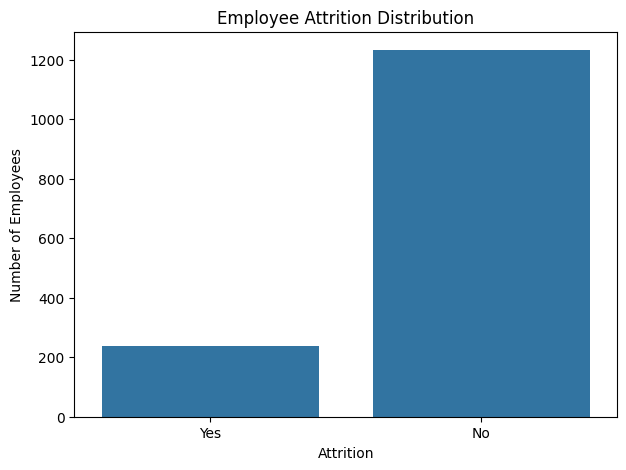

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [17]:
for column in df.columns:
    print(
        f"{column}: {df[column].nunique()} unique values"
    )

Age: 43 unique values
Attrition: 2 unique values
BusinessTravel: 3 unique values
DailyRate: 886 unique values
Department: 3 unique values
DistanceFromHome: 29 unique values
Education: 5 unique values
EducationField: 6 unique values
EmployeeCount: 1 unique values
EmployeeNumber: 1470 unique values
EnvironmentSatisfaction: 4 unique values
Gender: 2 unique values
HourlyRate: 71 unique values
JobInvolvement: 4 unique values
JobLevel: 5 unique values
JobRole: 9 unique values
JobSatisfaction: 4 unique values
MaritalStatus: 3 unique values
MonthlyIncome: 1349 unique values
MonthlyRate: 1427 unique values
NumCompaniesWorked: 10 unique values
Over18: 1 unique values
OverTime: 2 unique values
PercentSalaryHike: 15 unique values
PerformanceRating: 2 unique values
RelationshipSatisfaction: 4 unique values
StandardHours: 1 unique values
StockOptionLevel: 4 unique values
TotalWorkingYears: 40 unique values
TrainingTimesLastYear: 7 unique values
WorkLifeBalance: 4 unique values
YearsAtCompany: 37 uni

In [18]:
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique() <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['EmployeeCount', 'Over18', 'StandardHours']


In [19]:
columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df_model = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Original shape:", df.shape)
print("Modeling shape:", df_model.shape)

Original shape: (1470, 35)
Modeling shape: (1470, 31)


In [20]:
X = df_model.drop(
    "Attrition",
    axis=1
)

y = df_model["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

X shape: (1470, 30)
y shape: (1470,)

Target classes:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [21]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 23
Number of categorical features: 7

Numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1176
Testing samples: 294


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [24]:
def evaluate_model(model_name, model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    return {
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }

In [25]:
logistic_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [26]:
logistic_result = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

print(logistic_result)

{'ML Model Name': 'Logistic Regression', 'Accuracy': 0.8605442176870748, 'AUC': np.float64(0.8115255405289), 'Precision': 0.6153846153846154, 'Recall': 0.3404255319148936, 'F1 Score': 0.4383561643835616, 'MCC': np.float64(0.3871482408107933)}


In [27]:
decision_tree_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [28]:
decision_tree_result = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

print(decision_tree_result)

{'ML Model Name': 'Decision Tree', 'Accuracy': 0.7653061224489796, 'AUC': np.float64(0.6105177017830993), 'Precision': 0.3103448275862069, 'Recall': 0.3829787234042553, 'F1 Score': 0.34285714285714286, 'MCC': np.float64(0.20355850291983213)}


In [29]:
knn_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

knn_model.fit(
    X_train,
    y_train
)

print("KNN trained successfully!")

KNN trained successfully!


In [30]:
knn_result = evaluate_model(
    "KNN",
    knn_model,
    X_test,
    y_test
)

print(knn_result)

{'ML Model Name': 'KNN', 'Accuracy': 0.8435374149659864, 'AUC': np.float64(0.5946248600223965), 'Precision': 0.5384615384615384, 'Recall': 0.14893617021276595, 'F1 Score': 0.23333333333333334, 'MCC': np.float64(0.22220114340890812)}


In [31]:
naive_bayes_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        GaussianNB()
    )
])

naive_bayes_model.fit(
    X_train,
    y_train
)

print("Gaussian Naive Bayes trained successfully!")

Gaussian Naive Bayes trained successfully!


In [32]:
naive_bayes_result = evaluate_model(
    "Naive Bayes",
    naive_bayes_model,
    X_test,
    y_test
)

print(naive_bayes_result)

{'ML Model Name': 'Naive Bayes', 'Accuracy': 0.6462585034013606, 'AUC': np.float64(0.7031613403393919), 'Precision': 0.2605042016806723, 'Recall': 0.6595744680851063, 'F1 Score': 0.37349397590361444, 'MCC': np.float64(0.22645197588641655)}


In [33]:
random_forest_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [34]:
random_forest_result = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

print(random_forest_result)

{'ML Model Name': 'Random Forest', 'Accuracy': 0.8503401360544217, 'AUC': np.float64(0.8037298647600999), 'Precision': 0.6363636363636364, 'Recall': 0.14893617021276595, 'F1 Score': 0.2413793103448276, 'MCC': np.float64(0.25633958257904027)}


In [35]:
results = [
    logistic_result,
    decision_tree_result,
    knn_result,
    naive_bayes_result,
    random_forest_result
]

results_df = pd.DataFrame(results)

results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.860544,0.811526,0.615385,0.340426,0.438356,0.387148
1,Decision Tree,0.765306,0.610518,0.310345,0.382979,0.342857,0.203559
2,KNN,0.843537,0.594625,0.538462,0.148936,0.233333,0.222201
3,Naive Bayes,0.646259,0.703161,0.260504,0.659574,0.373494,0.226452
4,Random Forest,0.850340,0.803730,0.636364,0.148936,0.241379,0.256340


In [36]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_display = results_df.copy()

results_display[metric_columns] = (
    results_display[metric_columns]
    .round(4)
)

results_display

,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8605,0.8115,0.6154,0.3404,0.4384,0.3871
1,Decision Tree,0.7653,0.6105,0.3103,0.3830,0.3429,0.2036
2,KNN,0.8435,0.5946,0.5385,0.1489,0.2333,0.2222
3,Naive Bayes,0.6463,0.7032,0.2605,0.6596,0.3735,0.2265
4,Random Forest,0.8503,0.8037,0.6364,0.1489,0.2414,0.2563


In [37]:
results_df["Average Score"] = (
    results_df[metric_columns]
    .mean(axis=1)
)

winner_row = results_df.loc[
    results_df["Average Score"].idxmax()
]

print("Overall Winner:")
print(winner_row["ML Model Name"])

print("\nAverage Score:")
print(round(winner_row["Average Score"], 4))

Overall Winner:
Logistic Regression

Average Score:
0.5756


<Figure size 1200x600 with 0 Axes>

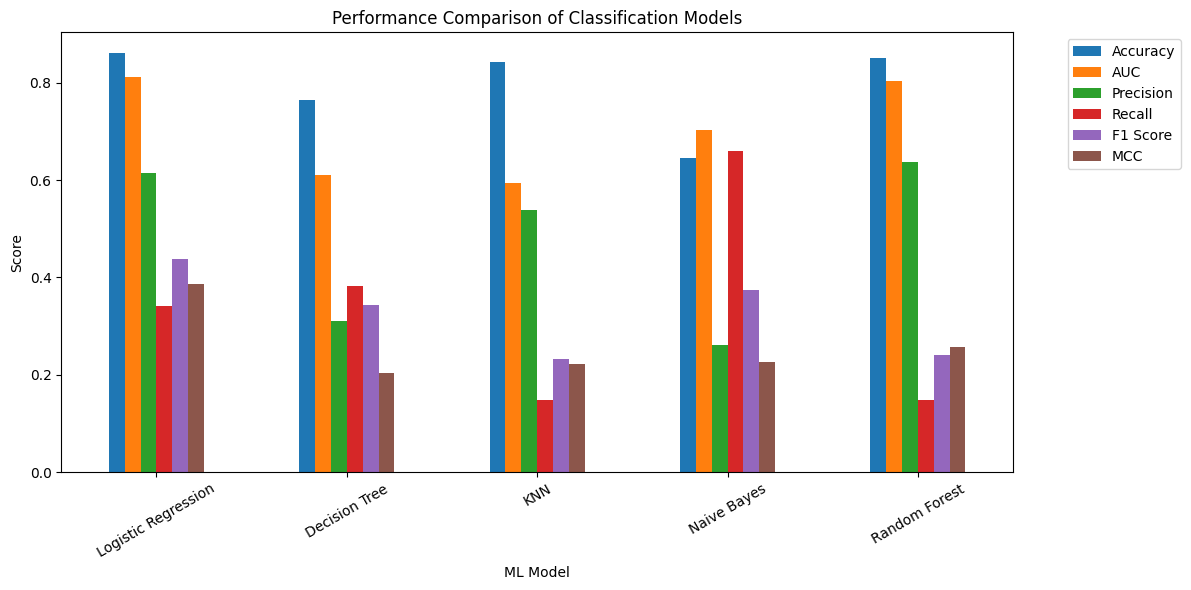

In [38]:
plt.figure(figsize=(12, 6))

comparison_plot = results_df.set_index(
    "ML Model Name"
)[metric_columns]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Performance Comparison of Classification Models"
)

plt.xlabel("ML Model")
plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [39]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "KNN": knn_model,
    "Naive Bayes": naive_bayes_model,
    "Random Forest": random_forest_model
}

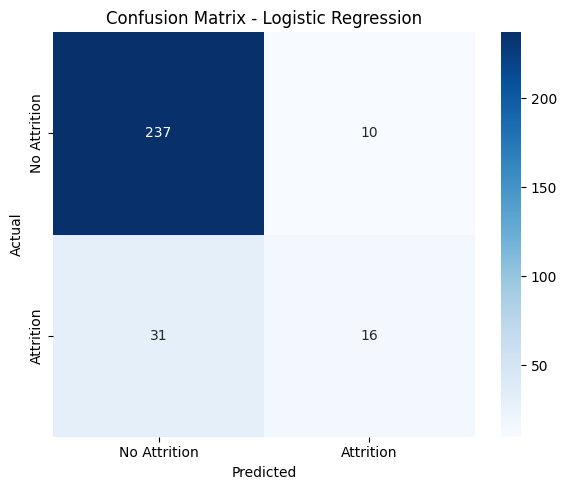

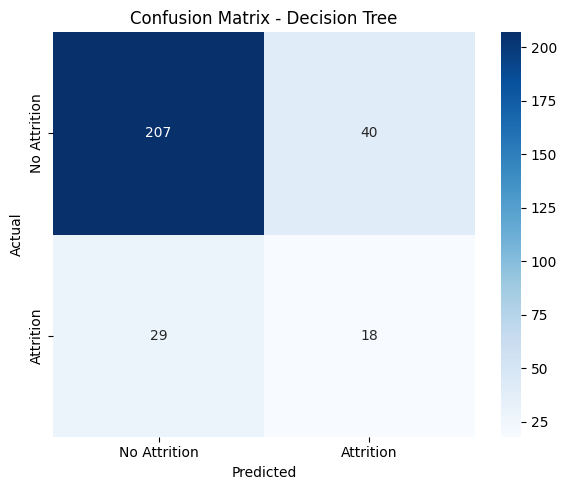

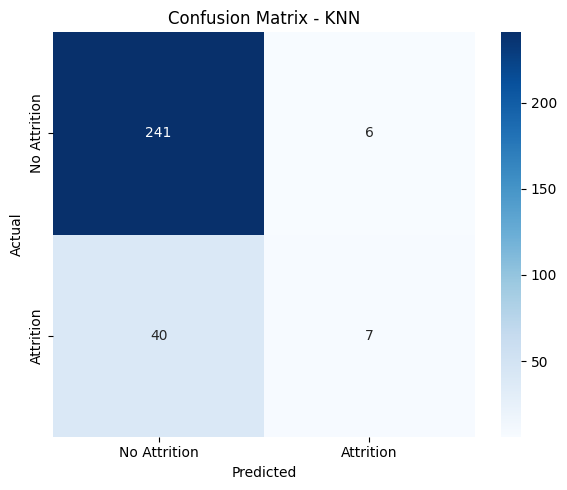

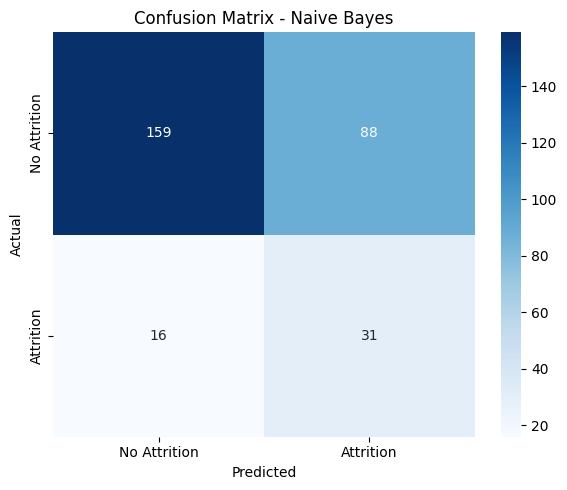

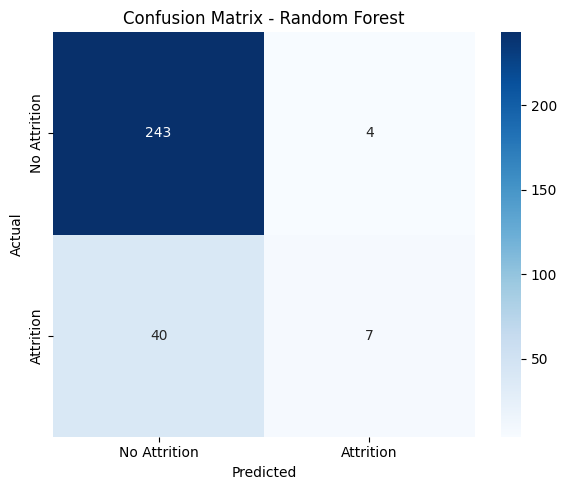

In [40]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "No Attrition",
            "Attrition"
        ],
        yticklabels=[
            "No Attrition",
            "Attrition"
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [41]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Attrition",
                "Attrition"
            ],
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.88      0.96      0.92       247
   Attrition       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



Decision Tree
              precision    recall  f1-score   support

No Attrition       0.88      0.84      0.86       247
   Attrition       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



KNN
              precision    recall  f1-score   support

No Attrition       0.86      0.98      0.91       247
   Attrition       0.54      0.15      0.23        47

    accuracy                           0.84       294
   macro avg       0.70      0.56      0.57       294
weighted avg       0.81      0

In [42]:
test_data = X_test.copy()

test_data["Attrition"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully!")
print("Shape:", test_data.shape)

test_data.csv created successfully!
Shape: (294, 31)


In [43]:
results_display.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "model_comparison.csv created successfully!"
)

model_comparison.csv created successfully!


In [44]:
os.makedirs(
    "model",
    exist_ok=True
)

joblib.dump(
    logistic_model,
    "model/logistic_regression.pkl"
)

joblib.dump(
    decision_tree_model,
    "model/decision_tree.pkl"
)

joblib.dump(
    knn_model,
    "model/knn.pkl"
)

joblib.dump(
    naive_bayes_model,
    "model/naive_bayes.pkl"
)

joblib.dump(
    random_forest_model,
    "model/random_forest.pkl"
)

print("All five models saved successfully!")

All five models saved successfully!


In [45]:
print("Files in current directory:\n")

for item in os.listdir("."):
    print(item)

Files in current directory:

.config
test_data.csv
model_comparison.csv
model
sample_data


In [46]:
print("\nFiles inside model folder:\n")

for item in os.listdir("model"):
    print(item)


Files inside model folder:

knn.pkl
decision_tree.pkl
random_forest.pkl
naive_bayes.pkl
logistic_regression.pkl


In [47]:
results_display

,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8605,0.8115,0.6154,0.3404,0.4384,0.3871
1,Decision Tree,0.7653,0.6105,0.3103,0.3830,0.3429,0.2036
2,KNN,0.8435,0.5946,0.5385,0.1489,0.2333,0.2222
3,Naive Bayes,0.6463,0.7032,0.2605,0.6596,0.3735,0.2265
4,Random Forest,0.8503,0.8037,0.6364,0.1489,0.2414,0.2563


Logistic Regression

Accuracy = 0.8605, AUC = 0.8115, F1 = 0.4384, MCC = 0.3871

This is the strongest overall model. It achieved the highest accuracy, AUC, F1-score and MCC. Its precision and recall are reasonably balanced compared with the other models. This indicates that Logistic Regression provides the most consistent overall classification performance for this dataset.

Decision Tree

Accuracy = 0.7653, AUC = 0.6105

Decision Tree produced the lowest accuracy among the five models and also had relatively low AUC, precision, F1-score and MCC. Its recall of 0.3830 was higher than Logistic Regression, KNN and Random Forest, but its overall performance was weaker.

KNN

Accuracy = 0.8435, AUC = 0.5946

KNN achieved relatively high accuracy, but its AUC was the lowest among all models. Its recall was only 0.1489, resulting in a low F1-score of 0.2333. Therefore, although KNN classified many instances correctly overall, it performed poorly in identifying positive attrition cases.

Naive Bayes

Accuracy = 0.6463, Recall = 0.6596

Naive Bayes had the highest recall among all models, meaning it identified the largest proportion of actual attrition cases. However, it had low precision (0.2605) and the lowest accuracy (0.6463). This indicates that it classified many employees as likely to leave, resulting in a relatively high number of false positives.

Random Forest

Accuracy = 0.8503, Precision = 0.6364, AUC = 0.8037

Random Forest performed strongly overall and achieved the highest precision among the five models. Its AUC was also high at 0.8037. However, its recall was only 0.1489, meaning it missed many actual attrition cases. Consequently, its F1-score and MCC were lower than Logistic Regression.

In [48]:
results_display.to_csv(
    "model_comparison.csv",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


In [49]:
import os

print("Current directory:")
print(os.getcwd())

print("\nModel files:")

for file in os.listdir("model"):
    print("✓", file)

print("\nTest data exists:", os.path.exists("test_data.csv"))
print("Comparison table exists:", os.path.exists("model_comparison.csv"))

Current directory:
/content

Model files:
✓ knn.pkl
✓ decision_tree.pkl
✓ random_forest.pkl
✓ naive_bayes.pkl
✓ logistic_regression.pkl

Test data exists: True
Comparison table exists: True


In [50]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Employee Attrition Classifier",
    page_icon="📊",
    layout="wide"
)

# ============================================================
# TITLE
# ============================================================

st.title("📊 Employee Attrition Classification")

st.markdown(
    """
    ### Machine Learning Model Comparison

    This application demonstrates employee attrition classification
    using five different machine learning models.

    **Models implemented:**
    - Logistic Regression
    - Decision Tree
    - K-Nearest Neighbors (KNN)
    - Gaussian Naive Bayes
    - Random Forest
    """
)

st.divider()

# ============================================================
# LOAD SAVED MODELS
# ============================================================

MODEL_PATHS = {
    "Logistic Regression": "model/logistic_regression.pkl",
    "Decision Tree": "model/decision_tree.pkl",
    "KNN": "model/knn.pkl",
    "Naive Bayes": "model/naive_bayes.pkl",
    "Random Forest": "model/random_forest.pkl"
}


@st.cache_resource
def load_models():

    loaded_models = {}

    for model_name, model_path in MODEL_PATHS.items():

        if os.path.exists(model_path):
            loaded_models[model_name] = joblib.load(model_path)

    return loaded_models


models = load_models()

# ============================================================
# CHECK MODELS
# ============================================================

if len(models) == 0:

    st.error(
        "No trained models were found. "
        "Please make sure the model folder contains the .pkl files."
    )

    st.stop()

# ============================================================
# MODEL SELECTION
# ============================================================

st.subheader("1️⃣ Select a Machine Learning Model")

selected_model_name = st.selectbox(
    "Choose a model:",
    list(models.keys())
)

selected_model = models[selected_model_name]

st.success(
    f"Selected Model: **{selected_model_name}**"
)

st.divider()

# ============================================================
# FILE UPLOAD
# ============================================================

st.subheader("2️⃣ Upload Test Dataset")

uploaded_file = st.file_uploader(
    "Upload test_data.csv",
    type=["csv"]
)

# ============================================================
# PROCESS UPLOADED FILE
# ============================================================

if uploaded_file is not None:

    try:

        test_data = pd.read_csv(uploaded_file)

        st.success("Dataset uploaded successfully!")

        # ----------------------------------------------------
        # Dataset information
        # ----------------------------------------------------

        st.subheader("Dataset Preview")

        st.dataframe(
            test_data.head(10),
            use_container_width=True
        )

        st.write(
            f"**Rows:** {test_data.shape[0]}  |  "
            f"**Columns:** {test_data.shape[1]}"
        )

        # ----------------------------------------------------
        # Check target
        # ----------------------------------------------------

        if "Attrition" not in test_data.columns:

            st.error(
                "The uploaded CSV must contain the "
                "'Attrition' column for evaluation."
            )

            st.stop()

        # ----------------------------------------------------
        # Separate features and target
        # ----------------------------------------------------

        X_test_app = test_data.drop(
            "Attrition",
            axis=1
        )

        y_test_app = test_data["Attrition"]

        # Handle target if it is stored as Yes/No
        if y_test_app.dtype == "object":

            y_test_app = y_test_app.map({
                "No": 0,
                "Yes": 1
            })

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        y_pred = selected_model.predict(
            X_test_app
        )

        # ----------------------------------------------------
        # Probability for AUC
        # ----------------------------------------------------

        if hasattr(
            selected_model,
            "predict_proba"
        ):

            y_prob = selected_model.predict_proba(
                X_test_app
            )[:, 1]

        else:

            y_prob = selected_model.decision_function(
                X_test_app
            )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_test_app,
            y_pred
        )

        auc = roc_auc_score(
            y_test_app,
            y_prob
        )

        precision = precision_score(
            y_test_app,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test_app,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test_app,
            y_pred,
            zero_division=0
        )

        mcc = matthews_corrcoef(
            y_test_app,
            y_pred
        )

        # ====================================================
        # DISPLAY METRICS
        # ====================================================

        st.subheader("3️⃣ Model Evaluation Metrics")

        col1, col2, col3 = st.columns(3)

        with col1:

            st.metric(
                "Accuracy",
                f"{accuracy:.4f}"
            )

        with col2:

            st.metric(
                "AUC",
                f"{auc:.4f}"
            )

        with col3:

            st.metric(
                "Precision",
                f"{precision:.4f}"
            )

        col4, col5, col6 = st.columns(3)

        with col4:

            st.metric(
                "Recall",
                f"{recall:.4f}"
            )

        with col5:

            st.metric(
                "F1 Score",
                f"{f1:.4f}"
            )

        with col6:

            st.metric(
                "MCC",
                f"{mcc:.4f}"
            )

        # ====================================================
        # CONFUSION MATRIX
        # ====================================================

        st.divider()

        st.subheader("4️⃣ Confusion Matrix")

        cm = confusion_matrix(
            y_test_app,
            y_pred
        )

        cm_df = pd.DataFrame(
            cm,
            index=[
                "Actual: No Attrition",
                "Actual: Attrition"
            ],
            columns=[
                "Predicted: No Attrition",
                "Predicted: Attrition"
            ]
        )

        st.dataframe(
            cm_df,
            use_container_width=True
        )

        # ====================================================
        # CLASSIFICATION REPORT
        # ====================================================

        st.subheader(
            "5️⃣ Classification Report"
        )

        report = classification_report(
            y_test_app,
            y_pred,
            target_names=[
                "No Attrition",
                "Attrition"
            ],
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(
            report
        ).transpose()

        st.dataframe(
            report_df.round(4),
            use_container_width=True
        )

        # ====================================================
        # PREDICTIONS
        # ====================================================

        st.subheader(
            "6️⃣ Prediction Results"
        )

        prediction_results = test_data.copy()

        prediction_results[
            "Predicted Attrition"
        ] = np.where(
            y_pred == 1,
            "Yes",
            "No"
        )

        st.dataframe(
            prediction_results,
            use_container_width=True
        )

        # ====================================================
        # DOWNLOAD PREDICTIONS
        # ====================================================

        csv_output = prediction_results.to_csv(
            index=False
        )

        st.download_button(
            label="⬇️ Download Predictions",
            data=csv_output,
            file_name="attrition_predictions.csv",
            mime="text/csv"
        )

    except Exception as e:

        st.error(
            "An error occurred while processing the dataset."
        )

        st.exception(e)

else:

    st.info(
        "Please upload the test_data.csv file to "
        "evaluate the selected model."
    )

# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Machine Learning Assignment 2 | "
    "Employee Attrition Classification"
)

Writing app.py


In [51]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn

Writing requirements.txt


In [52]:
import os
import shutil

project_dir = "/content/ML-Assignment-2"

os.makedirs(project_dir, exist_ok=True)
os.makedirs(
    os.path.join(project_dir, "model"),
    exist_ok=True
)

print("Project folder created:")
print(project_dir)

Project folder created:
/content/ML-Assignment-2


In [53]:
# Copy app.py
shutil.copy(
    "/content/app.py",
    project_dir
)

# Copy requirements.txt
shutil.copy(
    "/content/requirements.txt",
    project_dir
)

# Copy test data
shutil.copy(
    "/content/test_data.csv",
    project_dir
)

# Copy comparison results
shutil.copy(
    "/content/model_comparison.csv",
    project_dir
)

# Copy saved models
model_files = [
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl"
]

for model_file in model_files:

    shutil.copy(
        os.path.join(
            "/content/model",
            model_file
        ),
        os.path.join(
            project_dir,
            "model",
            model_file
        )
    )

print("All project files copied successfully!")

All project files copied successfully!


In [54]:
for root, dirs, files in os.walk(project_dir):

    level = root.replace(
        project_dir,
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for file in files:

        print(
            f"{indent}    {file}"
        )

ML-Assignment-2/
    app.py
    requirements.txt
    test_data.csv
    model_comparison.csv
    model/
        knn.pkl
        decision_tree.pkl
        random_forest.pkl
        naive_bayes.pkl
        logistic_regression.pkl


In [55]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 34.3 MB/s eta 0:00:00


In [56]:
!streamlit run /content/ML-Assignment-2/app.py &>/content/streamlit.log &

In [57]:
!cat /content/streamlit.log



2026-08-17 18:09:39.844 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.112.76.42:8501



In [58]:
import os

print(os.path.exists("/content/ML-Assignment-2/app.py"))
print(os.path.exists("/content/ML-Assignment-2/requirements.txt"))

print("\nModels:")

for file in os.listdir("/content/ML-Assignment-2/model"):
    print(file)

True
True

Models:
knn.pkl
decision_tree.pkl
random_forest.pkl
naive_bayes.pkl
logistic_regression.pkl


In [59]:
%%writefile /content/ML-Assignment-2/README.md

# Machine Learning Assignment 2
## Employee Attrition Classification

---

## 1. Problem Statement

Employee attrition is an important problem for organizations because unexpected employee turnover can increase recruitment costs, reduce productivity, and affect workforce planning.

The objective of this project is to develop and compare multiple machine learning classification models for predicting whether an employee is likely to leave the organization.

The target variable is **Attrition**, which has two classes:

- No — Employee does not leave
- Yes — Employee leaves

Five machine learning classification algorithms were implemented and evaluated using multiple performance metrics.

---

## 2. Dataset Description

The dataset used for this project is the IBM HR Analytics Employee Attrition & Performance dataset obtained from Kaggle.

The dataset contains information about employees, including demographic information, job characteristics, compensation, job satisfaction, work experience, and other employment-related attributes.

### Dataset Statistics

- Number of instances: 1470
- Number of original features/columns: 35
- Problem type: Binary Classification
- Target variable: Attrition

The target variable was converted into numerical form:

- No → 0
- Yes → 1

### Data Preprocessing

The following preprocessing steps were performed:

1. Checked for missing values.
2. Checked for duplicate records.
3. Removed irrelevant identifier/constant columns:
   - EmployeeNumber
   - EmployeeCount
   - Over18
   - StandardHours
4. Separated the target variable from the input features.
5. Numerical features were standardized using StandardScaler.
6. Categorical features were converted using OneHotEncoder.
7. The dataset was divided into training and testing sets using an 80:20 split.
8. Stratification was used to preserve the target class distribution.

---

## 3. Machine Learning Models

The following five classification algorithms were implemented:

### 1. Logistic Regression

Logistic Regression was used as a linear classification baseline for predicting employee attrition.

### 2. Decision Tree

Decision Tree is a rule-based tree model capable of learning nonlinear relationships between features and the target.

### 3. K-Nearest Neighbors (KNN)

KNN classifies observations based on the classes of nearby training observations.

### 4. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem and the assumption of conditional independence between features.

### 5. Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and robustness.

---

## 4. Evaluation Metrics

The models were evaluated using the following metrics:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

These metrics provide a broader evaluation than accuracy alone, especially because employee attrition is an imbalanced classification problem.

---

## 5. Model Comparison

| ML Model Name | Accuracy | AUC | Precision | Recall | F1 Score | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8605 | 0.8115 | 0.6154 | 0.3404 | 0.4384 | 0.3871 |
| Decision Tree | 0.7653 | 0.6105 | 0.3103 | 0.3830 | 0.3429 | 0.2036 |
| KNN | 0.8435 | 0.5946 | 0.5385 | 0.1489 | 0.2333 | 0.2222 |
| Naive Bayes | 0.6463 | 0.7032 | 0.2605 | 0.6596 | 0.3735 | 0.2265 |
| Random Forest | 0.8503 | 0.8037 | 0.6364 | 0.1489 | 0.2414 | 0.2563 |

---

## 6. Observations

### Logistic Regression

Logistic Regression achieved the highest accuracy (0.8605), AUC (0.8115), F1-score (0.4384), and MCC (0.3871). It provided the most balanced overall performance among the evaluated models.

### Decision Tree

Decision Tree achieved an accuracy of 0.7653 and an AUC of 0.6105. Its recall was 0.3830, but its precision, F1-score, and MCC were relatively low compared with Logistic Regression.

### KNN

KNN achieved relatively high accuracy (0.8435), but its AUC was only 0.5946 and its recall was 0.1489. Therefore, although it classified many observations correctly overall, it detected relatively few actual attrition cases.

### Naive Bayes

Naive Bayes achieved the highest recall of 0.6596, meaning it identified the largest proportion of actual attrition cases. However, it had low precision (0.2605) and the lowest accuracy (0.6463), indicating a relatively high number of false positive predictions.

### Random Forest

Random Forest achieved the highest precision of 0.6364 and a strong AUC of 0.8037. However, its recall was only 0.1489, resulting in a relatively low F1-score of 0.2414.

---

## 7. Overall Winner

### Logistic Regression

Logistic Regression was selected as the overall winner.

It achieved:

- Highest Accuracy: 0.8605
- Highest AUC: 0.8115
- Highest F1 Score: 0.4384
- Highest MCC: 0.3871

Although Random Forest achieved slightly higher precision and Naive Bayes achieved the highest recall, Logistic Regression provided the most balanced overall performance across the evaluation metrics.

---

## 8. Streamlit Application

A Streamlit application was developed to provide an interactive interface for evaluating the trained machine learning models.

The application provides:

1. CSV file upload
2. Machine learning model selection
3. Accuracy
4. AUC
5. Precision
6. Recall
7. F1 Score
8. MCC
9. Confusion matrix
10. Classification report
11. Prediction results
12. Downloadable prediction results

---

## 9. Repository Structure

```text
ML-Assignment-2/
│
├── app.py
├── requirements.txt
├── README.md
├── test_data.csv
├── model_comparison.csv
│
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    └── random_forest.pkl

Writing /content/ML-Assignment-2/README.md


In [60]:
import shutil

zip_path = shutil.make_archive(
    "/content/ML-Assignment-2",
    "zip",
    "/content/ML-Assignment-2"
)

print(zip_path)

/content/ML-Assignment-2.zip


In [61]:
from google.colab import files

files.download(
    "/content/ML-Assignment-2.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
import os

print("\nModel files:")

for f in os.listdir("/content/model"):
    if f.endswith(".pkl"):
        size = os.path.getsize("/content/model/" + f) / (1024 * 1024)
        print(f"{f}: {size:.2f} MB")


Model files:
knn.pkl: 0.47 MB
decision_tree.pkl: 0.03 MB
random_forest.pkl: 4.52 MB
naive_bayes.pkl: 0.01 MB
logistic_regression.pkl: 0.01 MB


In [63]:
import sys
import sklearn
import numpy
import scipy
import joblib
import pandas

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Joblib:", joblib.__version__)
print("Pandas:", pandas.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
NumPy: 2.0.2
SciPy: 1.16.3
Joblib: 1.5.3
Pandas: 2.2.2


In [64]:
import streamlit

print(streamlit.__version__)

1.61.1
